# Measure and correct an EBS machine with pySC and pyLOCO
This workflow assigns the two packages separate physical roles:

1. **pySC** creates the machine with errors and acts like the control system used to measure it.
2. **pyLOCO** fits a model to the measured orbit-response matrix (ORM).
3. The reconstructed quadrupole errors are converted into corrections, applied through pySC, and verified by remeasuring the machine.

## 1. Configuration
`ebs_conf_betamodel.yaml` defines the magnet, alignment, BPM, and corrector error distributions used to create the pySC state. `pyloco_config.yaml` controls how the machine is measured and fitted.

By default `measurement.source` is `simulate`, so the notebook performs new pySC measurements. Set it to `cached` to use the preserved measurement files for a faster demonstration.

In [2]:
import copy
import numpy as np
from example_pysc_simulated_commissioning import (
    HERE, acquire_measurement, apply_pyloco_correction, load_config,
    load_pysc_machine, make_plots, measure_orm_with_pysc, print_optics_summary,
    run_fit, selected_indices,
)
from pyLOCO.config import RMConfig
from pyLOCO.response_matrix import response_matrix
config_path = HERE / 'pyloco_config.yaml'
cfg = load_config(config_path)

## 2. Restore the simulated machine
The saved pySC state is one reproducible realization of the configured errors. `lattice.design` is the ideal reference and `lattice.ring` is the simulated machine seen by the measurement system.

In [3]:
commissioning = load_pysc_machine(config_path, cfg)
ideal = commissioning.lattice.design
machine_before_correction = copy.deepcopy(commissioning.lattice.ring)
ideal.disable_6d(); machine_before_correction.disable_6d()
bpm, correctors, quads, cavities = selected_indices(ideal, cfg)
print(f'{len(bpm)} BPMs, {len(correctors)} correctors, {len(quads)} fitted quadrupoles')

/Users/musa/my_project/venv/lib/python3.14/site-packages/scipy/io/matlab/_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


320 BPMs, 288 correctors, 252 fitted quadrupoles


## 3. Measure the machine with pySC
In live mode, pySC performs three operations:

- `measure_OrbitResponseMatrix` applies positive and negative horizontal and vertical corrector kicks and reads every BPM.
- `measure_RFFrequencyOrbitResponse` changes the RF frequency in both directions to obtain the dispersion-like orbit response.
- `get_average_orbit` repeats the orbit reading to estimate BPM uncertainty.

These are simulated control-system measurements of the machine with errors—not response matrices calculated directly from the ideal AT model.

In [4]:
orm, eta_x, eta_y, weights = acquire_measurement(commissioning, HERE, cfg)
print('Measured ORM:', orm.shape)
print('BPM uncertainty vector:', weights.shape)
print('Measurement source:', cfg['measurement']['source'])

Measuring ORM, RF response, and BPM repeatability with pySC ...
11 Aug 2026, 15:09:57 | INFO | Measuring orbit response matrix.
11 Aug 2026, 15:14:10 | INFO | Measuring orbit response to RF frequency (dispersion).
Measured ORM: (640, 576)
BPM uncertainty vector: (640,)
Measurement source: simulate


## 4. Calculate the ideal-model response
This AT calculation is not the measurement. It is pyLOCO's initial model prediction, using the same BPMs, correctors, and kick amplitude as pySC.

In [5]:
kick = float(cfg['measurement']['corrector_kick_rad'])
rm_cfg = RMConfig(
    bpm_ords=bpm, cm_ords=[correctors, correctors],
    dkick=[[kick] * len(correctors)] * 2, bidirectional=True,
)
initial_orm = response_matrix(ideal, config=rm_cfg)
initial_residual = np.sqrt(np.mean((initial_orm - orm)**2))
print(f'Ideal model − pySC measurement: {1e6*initial_residual:.6f} µm RMS')

Ideal model − pySC measurement: 15.476206 µm RMS


## 5. Reconstruct the errors with pyLOCO
pyLOCO varies the parameter blocks listed in YAML until the model ORM reproduces the pySC measurement. `FitInitConfig` comes from `pyLOCO.config`; temporary Jacobians and logs are removed automatically.

In [6]:
result = run_fit(ideal, bpm, correctors, quads, cavities, orm, eta_x, eta_y, weights, cfg)
_, fit_dict, fitted, fitted_orm, _, chi2, _, _ = result
fit_residual = np.sqrt(np.mean((fitted_orm - orm)**2))
print(f'Fitted model − pySC measurement: {1e6*fit_residual:.6f} µm RMS')


==== Iteration 1/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_ebs_pysc_3_4wji_w/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 30.5 s
[Jacobian] Saved normal-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_ebs_pysc_3_4wji_w/jacobians/quads/J_quads_iter1_0.0001urad_-3000.0Hz.h5
   No outliers in the data set.
Initial Chi²: 5.0987e+06
  LM inner 1: chi² 8.5302e+04 (previous 5.0987e+06), λ=0.001
Chi² after correction: 8.5302e+04

==== Iteration 2/5 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_ebs_pysc_3_4wji_w/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 19.5 s
   No outliers in the data set.
Initial Chi²: 8.5302e+04
  LM inner 1: chi² 7.1844e+04 (previous 8.5302e+04), λ=0.001

## 6. Apply the correction back to pySC
For every fitted quadrupole, the reconstructed error is

`K_fitted − K_ideal`.

The correction is its opposite. It is applied through `commissioning.magnet_settings`, representing a change sent to the simulated machine rather than merely editing the fitted model.

In [7]:
correction = apply_pyloco_correction(commissioning, ideal, fitted, quads)
corrected_machine = copy.deepcopy(commissioning.lattice.ring)
corrected_machine.disable_6d()
print(f'Applied {len(correction)} quadrupole corrections through pySC')
print(f'Largest |ΔK correction|: {np.max(np.abs(correction)):.6e} m^-2')

Applied 252 quadrupole corrections through pySC
Largest |ΔK correction|: 3.243868e-02 m^-2


## 7. Remeasure the corrected machine
The final check uses pySC to measure the ORM again. Comparing this new measurement with the ideal ORM tests whether the physical correction improved the simulated machine.

In [8]:
corrected_orm = measure_orm_with_pysc(commissioning, cfg)
corrected_residual = np.sqrt(np.mean((corrected_orm - initial_orm)**2))
print(f'Original pySC machine − ideal:  {1e6*initial_residual:.6f} µm RMS')
print(f'Corrected pySC machine − ideal: {1e6*corrected_residual:.6f} µm RMS')

11 Aug 2026, 15:18:17 | INFO | Measuring orbit response matrix.
Original pySC machine − ideal:  15.476206 µm RMS
Corrected pySC machine − ideal: 5.710449 µm RMS


## 8. Print beta beating and dispersion before and after correction
This table is the numerical counterpart of the optics plots. It reports RMS horizontal and vertical beta beating in percent and RMS horizontal and vertical dispersion error in millimetres. Every value is calculated relative to the ideal EBS lattice.

In [ ]:
print_optics_summary(
    ideal,
    machine_before_correction,
    fitted,
    corrected_machine,
)

## 9. Interpret the result
The plots answer four questions: Did pyLOCO reproduce the measurement? Did chi-square converge? Do reconstructed quadrupole errors resemble the known pySC errors? Did applying the correction improve the actual simulated machine?

The optics validation contains separate horizontal and vertical beta-beating and dispersion-error panels. The original pySC machine is solid red, the fitted lattice is dashed blue, and the corrected pySC machine is dash-dot green. All curves are differences relative to the ideal EBS lattice.

Saved: /Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/com_simu_loco_example/output/pysc_simulated_commissioning/orm_residual_before_after.png


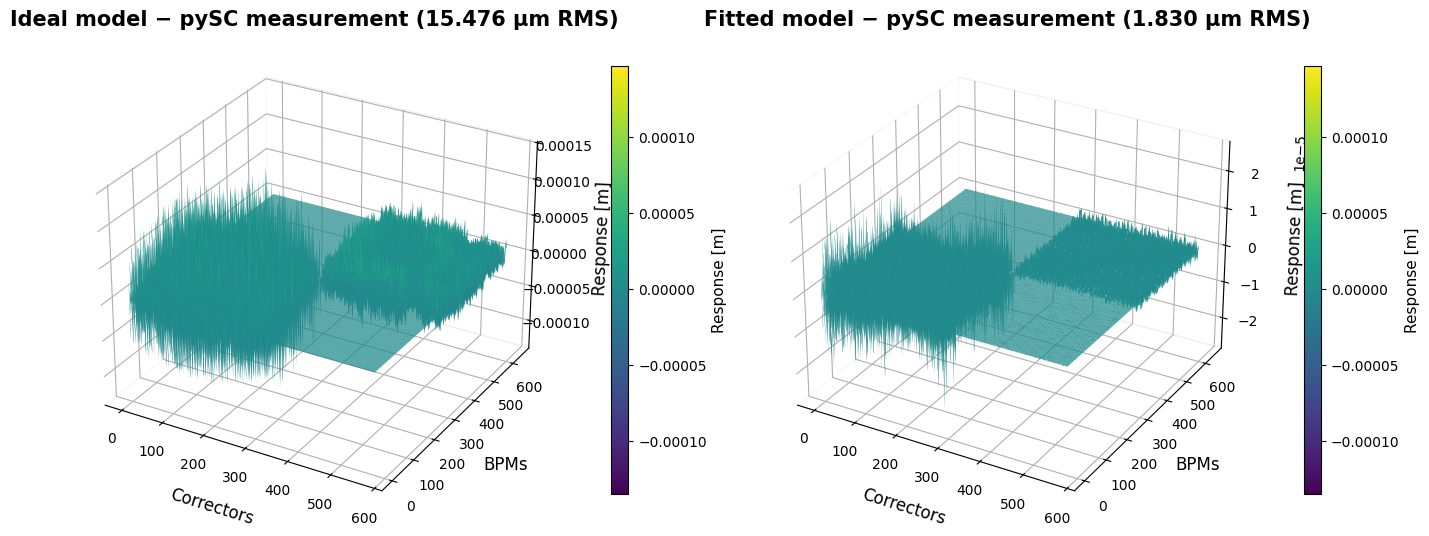

Saved: /Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/com_simu_loco_example/output/pysc_simulated_commissioning/orm_correction_on_machine.png


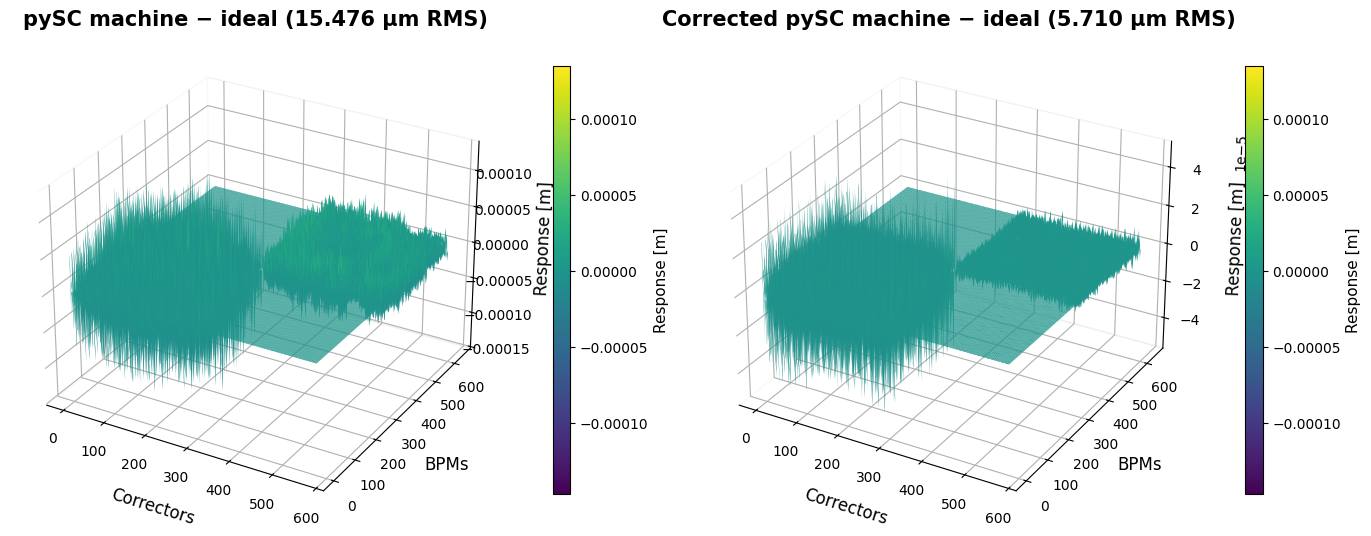

ORM fit improvement: 8.458x
Machine correction improvement: 2.710x
Figures: /Users/musa/Desktop/pyLOCO/Examples/EBS_pySC/com_simu_loco_example/output/pysc_simulated_commissioning


In [9]:
output = HERE / cfg['output']['directory']
make_plots(
    output, ideal, machine_before_correction, fitted, corrected_machine, quads,
    orm, corrected_orm, initial_orm, fitted_orm, chi2,
)
print(f'ORM fit improvement: {initial_residual/fit_residual:.3f}x')
print(f'Machine correction improvement: {initial_residual/corrected_residual:.3f}x')
print('Figures:', output)